# LipNet — Faza 2 na GPU-u

Samostalan notebook: upload `processed.zip` → manifest/split/vokabular → CUDA mouth ROI → QA slika → `faza2_artifacts.zip`.

> Pre pokretanja izaberi **Runtime → Change runtime type → T4 GPU**. Pokreni **Runtime → Run all**.

In [1]:
import subprocess, sys, torch
assert torch.cuda.is_available(), 'GPU nije uključen. Izaberi Runtime → Change runtime type → T4 GPU.'
print('GPU:', torch.cuda.get_device_name(0))
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'face-alignment==1.5.0'], check=True)

GPU: Tesla T4


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'face-alignment==1.5.0'], returncode=0)

## Upload korpusa

Klikni **Choose Files** i izaberi lokalni `processed.zip`. Upload od oko 4 GB može potrajati. Ako se Colab diskonektuje, koristi opcionu Drive ćeliju ispod umesto ove.

In [ ]:
from google.colab import files
from pathlib import Path
import shutil, zipfile

uploaded = files.upload()
zip_names = [name for name in uploaded if name.lower().endswith('.zip')]
assert len(zip_names) == 1, 'Izaberi tačno jedan processed.zip fajl.'
ZIP_PATH = Path('/content') / zip_names[0]
print('Upload završen:', ZIP_PATH)

### Opciono: učitaj ZIP sa Google Drive-a

Ovu ćeliju pokreni **samo umesto upload ćelije** ako je fajl već na `MyDrive/processed.zip`.

In [5]:
from google.colab import files
from pathlib import Path
import shutil, zipfile
# OPCIONO — preskoči ako si uploadovao ZIP iz prethodne ćelije.
from google.colab import drive
drive.mount('/content/drive')
ZIP_PATH = Path('/content/drive/MyDrive/processed.zip')
assert ZIP_PATH.exists(), ZIP_PATH

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
DATA_DIR = Path('/content/faza2_data')
if DATA_DIR.exists(): shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir()
with zipfile.ZipFile(ZIP_PATH) as archive:
    archive.extractall(DATA_DIR)
candidates = [DATA_DIR/'processed'/'processed', DATA_DIR/'processed', DATA_DIR]
CORPUS = next((p for p in candidates if any(p.glob('spk*/alignment/*.align'))), None)
assert CORPUS is not None, 'Nije pronađena struktura spk*/alignment/*.align.'
videos = list(CORPUS.glob('spk*/ser/video_a/*.mp4'))
aligns = list(CORPUS.glob('spk*/alignment/*.align'))
print('Korpus:', CORPUS, '| MP4:', len(videos), '| ALIGN:', len(aligns))
assert len(videos) == len(aligns) == 3957, 'Očekivano je 3.957 MP4 i ALIGN fajlova.'

Korpus: /content/faza2_data/processed | MP4: 3957 | ALIGN: 3957


## Manifest, speaker-disjunktni split i 29 CTC klasa

In [7]:
import csv, json, random, unicodedata, cv2
from collections import defaultdict

OUT = Path('/content/phase2')
OUT.mkdir(exist_ok=True)
VOCAB = ['<blank>', ' ', *list('abcčćdđefghijklmnoprsštuvzž')]
assert len(VOCAB) == 29 and len(set(VOCAB)) == 29
videos = {p.stem:p for p in CORPUS.glob('spk*/ser/video_a/*.mp4')}
aligns = {p.stem:p for p in CORPUS.glob('spk*/alignment/*.align')}
assert videos.keys() == aligns.keys(), 'Postoje neupareni MP4/ALIGN fajlovi.'
rows = []
for i, sample_id in enumerate(sorted(videos), 1):
    tokens=[]
    for line in aligns[sample_id].read_text(encoding='utf-8-sig').splitlines():
        parts=line.split('\t')
        if len(parts)==3 and parts[2].strip().lower()!='sil':
            tokens.append(unicodedata.normalize('NFC', parts[2].strip().lower()))
    transcript=' '.join(tokens)
    cap=cv2.VideoCapture(str(videos[sample_id])); n=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); fps=float(cap.get(cv2.CAP_PROP_FPS)); w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)); cap.release()
    min_ctc=len(transcript)+sum(a==b for a,b in zip(transcript, transcript[1:]))
    assert transcript and not (set(transcript)-set(VOCAB[1:])) and min_ctc<=n
    rows.append(dict(sample_id=sample_id,speaker_id=sample_id.split('_')[0],video_path=videos[sample_id].relative_to(CORPUS).as_posix(),alignment_path=aligns[sample_id].relative_to(CORPUS).as_posix(),transcript=transcript,duration_s=round(n/fps,6),num_frames=n,fps=round(fps,6),width=w,height=h,target_length=len(transcript),min_ctc_frames=min_ctc))
    if i%500==0: print('Manifest:',i,'/3957')
with (OUT/'manifest.csv').open('w',encoding='utf-8',newline='') as f:
    writer=csv.DictWriter(f,fieldnames=rows[0].keys()); writer.writeheader(); writer.writerows(rows)
speakers=sorted({r['speaker_id'] for r in rows}); random.Random(42).shuffle(speakers)
split_speakers={'train':sorted(speakers[6:]),'validation':sorted(speakers[3:6]),'test':sorted(speakers[:3])}
split={'seed':42,'speakers':split_speakers}
for name,members in split_speakers.items(): split[name]=[r['sample_id'] for r in rows if r['speaker_id'] in set(members)]
assert not (set(split_speakers['train'])&set(split_speakers['validation']) | set(split_speakers['train'])&set(split_speakers['test']) | set(split_speakers['validation'])&set(split_speakers['test']))
(OUT/'split.json').write_text(json.dumps(split,ensure_ascii=False,indent=2)+'\n',encoding='utf-8')
vocab={'blank_id':0,'space_id':1,'symbols':VOCAB,'symbol_to_id':{s:i for i,s in enumerate(VOCAB)}}
(OUT/'vocab.json').write_text(json.dumps(vocab,ensure_ascii=False,indent=2)+'\n',encoding='utf-8')
print('Gotovo:',len(rows),'primera,',len(speakers),'govornika; split:',{k:len(split[k]) for k in ('train','validation','test')})

Manifest: 500 /3957
Manifest: 1000 /3957
Manifest: 1500 /3957
Manifest: 2000 /3957
Manifest: 2500 /3957
Manifest: 3000 /3957
Manifest: 3500 /3957
Gotovo: 3957 primera, 22 govornika; split: {'train': 2877, 'validation': 540, 'test': 540}


## CUDA landmark detekcija i stabilan mouth ROI

In [8]:
import face_alignment, numpy as np, statistics, time
fa=face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D,device='cuda',face_detector='sfd',flip_input=False,compile=False,max_batch_size=8)
def median_box(boxes): return tuple(statistics.median(v) for v in zip(*boxes))
def norm_box(mouth,w,h):
    xs=(mouth[:,0]/w).tolist(); ys=(mouth[:,1]/h).tolist(); cx=(min(xs)+max(xs))/2; cy=(min(ys)+max(ys))/2
    bw=max(max(xs)-min(xs),.04)*1.55; bh=max(max(ys)-min(ys),.025)*2; bw=max(bw,bh*2); bh=bw/2
    x1,x2=cx-bw/2,cx+bw/2; y1,y2=cy-bh/2,cy+bh/2
    sx=max(0,-x1)-max(0,x2-1); sy=max(0,-y1)-max(0,y2-1)
    return x1+sx,y1+sy,x2+sx,y2+sy
detections={}; counts={}; speaker_boxes=defaultdict(list); started=time.time()
for idx,row in enumerate(rows,1):
    cap=cv2.VideoCapture(str(CORPUS/row['video_path'])); n=row['num_frames']; boxes=[]
    for pos in [round(n*(.15+.7*i/4)) for i in range(5)]:
        cap.set(cv2.CAP_PROP_POS_FRAMES,min(pos,n-1)); ok,frame=cap.read()
        if not ok: continue
        scale=min(1.,640/max(frame.shape[:2])); frame=cv2.resize(frame,None,fx=scale,fy=scale,interpolation=cv2.INTER_AREA) if scale<1 else frame
        rgb=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB); pred=fa.get_landmarks_from_image(rgb)
        if pred is not None and len(pred): boxes.append(norm_box(np.asarray(pred[0])[48:68],rgb.shape[1],rgb.shape[0]))
    cap.release(); box=median_box(boxes) if boxes else None; detections[row['sample_id']]=box; counts[row['sample_id']]=len(boxes)
    if box is not None: speaker_boxes[row['speaker_id']].append(box)
    if idx%100==0: print(f'GPU ROI: {idx}/{len(rows)} | {((time.time()-started)/60):.1f} min')
valid=[b for b in detections.values() if b is not None]; assert valid,'Nema uspešnih detekcija'
global_box=median_box(valid); speaker_medians={s:median_box(b) for s,b in speaker_boxes.items()}; roi_rows=[]
for row in rows:
    box=detections[row['sample_id']]; source='face_alignment_cuda'
    if box is None: box=speaker_medians.get(row['speaker_id'],global_box); source='speaker_median' if row['speaker_id'] in speaker_medians else 'global_median'
    roi_rows.append(dict(sample_id=row['sample_id'],x1=box[0],y1=box[1],x2=box[2],y2=box[3],valid_detections=counts[row['sample_id']],sampled_frames=5,source=source))
with (OUT/'roi.csv').open('w',encoding='utf-8',newline='') as f:
    writer=csv.DictWriter(f,fieldnames=roi_rows[0].keys()); writer.writeheader(); writer.writerows(roi_rows)
print('ROI završeno; fallback:',sum(r['source']!='face_alignment_cuda' for r in roi_rows))

Downloading: "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" to /root/.cache/torch/hub/checkpoints/s3fd-619a316812.pth


100%|██████████| 85.7M/85.7M [00:05<00:00, 16.5MB/s]
Downloading: "https://www.adrianbulat.com/downloads/python-fan/2DFAN4-11f355bf06.pth.tar" to /root/.cache/torch/hub/checkpoints/2DFAN4-11f355bf06.pth.tar
100%|██████████| 91.2M/91.2M [00:06<00:00, 15.9MB/s]


GPU ROI: 100/3957 | 3.0 min
GPU ROI: 200/3957 | 5.6 min
GPU ROI: 300/3957 | 8.0 min
GPU ROI: 400/3957 | 10.3 min
GPU ROI: 500/3957 | 12.5 min
GPU ROI: 600/3957 | 14.9 min
GPU ROI: 700/3957 | 17.5 min
GPU ROI: 800/3957 | 19.4 min
GPU ROI: 900/3957 | 21.0 min
GPU ROI: 1000/3957 | 23.5 min
GPU ROI: 1100/3957 | 26.2 min
GPU ROI: 1200/3957 | 29.1 min
GPU ROI: 1300/3957 | 31.9 min
GPU ROI: 1400/3957 | 34.8 min
GPU ROI: 1500/3957 | 37.3 min
GPU ROI: 1600/3957 | 39.5 min
GPU ROI: 1700/3957 | 42.8 min
GPU ROI: 1800/3957 | 45.9 min
GPU ROI: 1900/3957 | 49.3 min
GPU ROI: 2000/3957 | 52.5 min
GPU ROI: 2100/3957 | 55.1 min
GPU ROI: 2200/3957 | 57.7 min
GPU ROI: 2300/3957 | 60.3 min
GPU ROI: 2400/3957 | 62.7 min
GPU ROI: 2500/3957 | 65.1 min
GPU ROI: 2600/3957 | 67.3 min
GPU ROI: 2700/3957 | 69.4 min
GPU ROI: 2800/3957 | 72.3 min
GPU ROI: 2900/3957 | 75.4 min
GPU ROI: 3000/3957 | 78.2 min
GPU ROI: 3100/3957 | 80.8 min
GPU ROI: 3200/3957 | 83.5 min
GPU ROI: 3300/3957 | 85.8 min
GPU ROI: 3400/3957 | 8

## QA slika — svi govornici i najduži klipovi

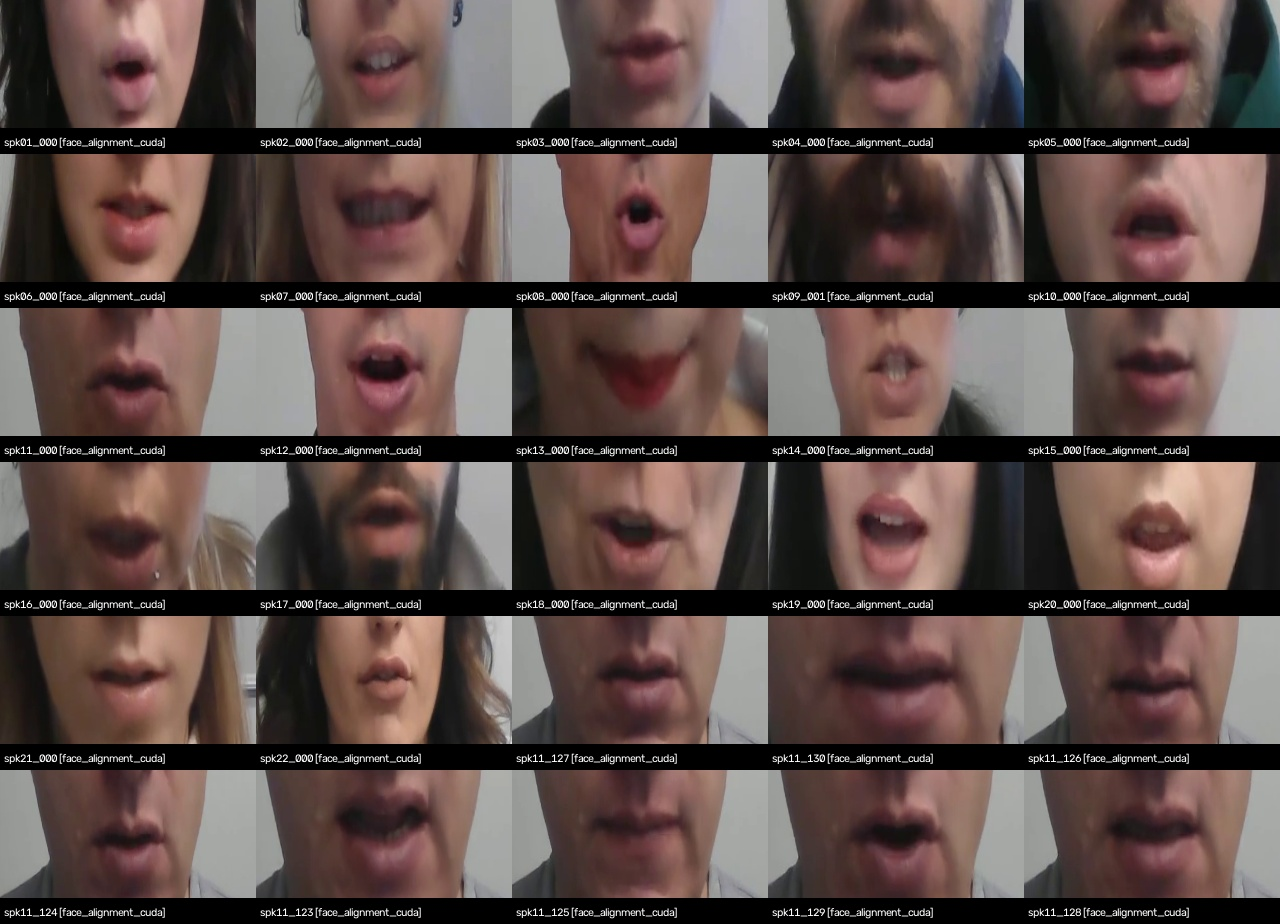

In [9]:
roi_by_id={r['sample_id']:r for r in roi_rows}; chosen=[]; seen=set()
for r in rows:
    if r['speaker_id'] not in seen: chosen.append(r); seen.add(r['speaker_id'])
for r in sorted(rows,key=lambda x:x['num_frames'],reverse=True):
    if len(chosen)>=30: break
    if r not in chosen: chosen.append(r)
tiles=[]
for r in chosen:
    cap=cv2.VideoCapture(str(CORPUS/r['video_path'])); cap.set(cv2.CAP_PROP_POS_FRAMES,r['num_frames']//2); ok,frame=cap.read(); cap.release()
    if not ok: continue
    q=roi_by_id[r['sample_id']]; h,w=frame.shape[:2]; crop=frame[int(q['y1']*h):int(q['y2']*h),int(q['x1']*w):int(q['x2']*w)]
    crop=cv2.resize(crop,(256,128)); tile=np.zeros((154,256,3),np.uint8); tile[:128]=crop
    cv2.putText(tile,f"{r['sample_id']} [{q['source']}]",(4,146),cv2.FONT_HERSHEY_SIMPLEX,.38,(255,255,255),1); tiles.append(tile)
while len(tiles)%5: tiles.append(np.zeros_like(tiles[0]))
sheet=np.vstack([np.hstack(tiles[i:i+5]) for i in range(0,len(tiles),5)]); cv2.imwrite(str(OUT/'roi_qa.jpg'),sheet)
qa={'backend':'face-alignment','device':'cuda','face_detector':'sfd','samples_per_video':5,'fallback_count':sum(r['source']!='face_alignment_cuda' for r in roi_rows),'sample_ids':[r['sample_id'] for r in chosen],'manual_review_complete':False}
(OUT/'roi_qa.json').write_text(json.dumps(qa,ensure_ascii=False,indent=2)+'\n',encoding='utf-8')
from IPython.display import display, Image
display(Image(filename=str(OUT/'roi_qa.jpg')))

## Potvrda QA i preuzimanje

Pregledaj sliku iznad. Ako crop-ovi pravilno obuhvataju usne, upiši `DA` i pokreni ćeliju.

In [10]:
potvrda=input('Da li je ručni QA uspešan? Upiši DA: ').strip().upper()
assert potvrda=='DA','Artefakti nisu označeni kao ručno pregledani.'
qa=json.loads((OUT/'roi_qa.json').read_text(encoding='utf-8')); qa['manual_review_complete']=True
(OUT/'roi_qa.json').write_text(json.dumps(qa,ensure_ascii=False,indent=2)+'\n',encoding='utf-8')
archive=shutil.make_archive('/content/faza2_artifacts','zip',OUT)
print('Sadržaj:',sorted(p.name for p in OUT.iterdir()))
files.download(archive)

Da li je ručni QA uspešan? Upiši DA: DA
Sadržaj: ['manifest.csv', 'roi.csv', 'roi_qa.jpg', 'roi_qa.json', 'split.json', 'vocab.json']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>